# Tapering granularity: Scenario 2 with dipole trims

This follows Scenario 1, but the final horizontal-orbit correction uses one trim on the first bend of every three-dipole cell in the arc+DS regions.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xobjects as xo
import xtrack as xt
import re

from tapering import *

In [2]:
line_path = "../acc-models-fcc-ee/lattices/t/fccee_t_merged_dipoles.json"

## Ideal Xsuite tapering

In [3]:
line = xt.load(line_path).fccee_p_ring
line.build_tracker(_context=xo.ContextCpu())
line.configure_radiation(model='mean')

Loading line from dict: 100%|██████████| 18995/18995 [00:05<00:00, 3592.76it/s]


In [4]:
line.compensate_radiation_energy_loss(delta0='zero_mean')

Compensating energy loss.
Share energy loss among cavities (repeat until energy loss is zero)
Energy loss: 8_148_214_673.634 eV             
Energy loss: 547_159_865.896 eV             
Energy loss: 39_263_508.462 eV             
Energy loss: 2_830_019.620 eV             
Energy loss: 204_045.915 eV             
Energy loss: 14_712.158 eV             
Energy loss: 1_060.780 eV             
Energy loss: 76.485 eV             
Energy loss: 5.516 eV             
Energy loss: 187_227_640.077 eV             
Energy loss: 30_859_907.300 eV             
Energy loss: -8_193_207.838 eV             
Energy loss: -3_540_866.802 eV             
Energy loss: -2_868.191 eV             
Energy loss: 250_680.922 eV             
Energy loss: 41_550.545 eV             
Energy loss: -10_927.730 eV             
Energy loss: -4_749.635 eV             
Energy loss: -8.290 eV             

  - Set delta_taper
  - Restore cavity voltage and frequency. Set cavity lag


In [5]:
elements_with_taper = np.asarray([ name for name in line.element_names if hasattr(line[name], "delta_taper")], dtype=str)
ideal_delta_taper = np.asarray([float(line[name].delta_taper) for name in elements_with_taper], dtype=float).copy()
ideal_taper_by_name = dict(zip(elements_with_taper, ideal_delta_taper))
twiss_ideal = line.twiss(eneloss_and_damping=True, radiation_analysis=True)
tt  = line.get_table()
print(f'Taperable elements: {len(ideal_delta_taper)}')
print(f'Ideal emittance: x={float(twiss_ideal.eq_gemitt_x)*1e9:.4g} nm, y={float(twiss_ideal.eq_gemitt_y)*1e12:.4g} pm')

/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/twiss/twiss_defaults_and_input_preparation.py:501: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Taperable elements: 15985
Ideal emittance: x=2.189 nm, y=0.06379 pm


In [6]:
def clear_delta_taper(line, elements_with_taper ):
    for name in elements_with_taper:
        line[name].delta_taper = 0.0

def restore_ideal_tapering(line,elements_with_taper, ideal_delta_taper):
    for name, value in zip(elements_with_taper, ideal_delta_taper):
        line[name].delta_taper = float(value)


def read_rf_phase(line):
    rows = []

    for name in line.element_names:
        element = line[name]

        if not hasattr(element, "voltage"):
            continue

        voltage = float(element.voltage)

        if voltage == 0:
            continue

        phase_taper = float(
            getattr(element, "phase_taper", 0.0)
        )

        rows.append({
            "name": name,
            "voltage_MV": voltage * 1e-6,
            "phase_taper_rad": phase_taper,
            "phase_taper_deg": np.rad2deg(phase_taper),
        })

    return pd.DataFrame(rows)

In [7]:
rf_phase_ideal = read_rf_phase(line)
rf_phase_ideal 

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103167,-63.206841
1,rf800.0,4020.0,-1.103153,-63.206005
2,rf800.1,4020.0,-1.103153,-63.206005
3,rf400.1,990.0,-1.103167,-63.206841


In [8]:
clear_delta_taper(line, elements_with_taper)
# get_rf_phase(line, delta0='zero_mean', rtol_eneloss=1e-12, max_iter=100, verbose=True, co_search_at=None)
get_rf_phase(line)
rf_phase_no_tapering = read_rf_phase(line)

/eos/home-d/ddomange/Documents/FCCeeCircuitCriticality/FCCee_tapering/tapering.py:115: RuntimeWarning: RF near its limit (get_rf_phase iteration 0): sin(phase_s) = 0.9090, phase_s = 65.37 deg, 9.1% headroom to crest.
  inst_phase = np.arcsin(_check_rf_headroom(egain / v0, context, rf_warn_ratio))
/eos/home-d/ddomange/Documents/FCCeeCircuitCriticality/FCCee_tapering/tapering.py:115: RuntimeWarning: RF near its limit (get_rf_phase iteration 1): sin(phase_s) = 0.9090, phase_s = 65.37 deg, 9.1% headroom to crest.
  inst_phase = np.arcsin(_check_rf_headroom(egain / v0, context, rf_warn_ratio))


In [9]:
rf_phase_ideal

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103167,-63.206841
1,rf800.0,4020.0,-1.103153,-63.206005
2,rf800.1,4020.0,-1.103153,-63.206005
3,rf400.1,990.0,-1.103167,-63.206841


In [10]:
rf_phase_no_tapering

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.122084,-64.290690
1,rf800.0,4020.0,-1.140986,-65.373703
2,rf800.1,4020.0,-1.140986,-65.373703
3,rf400.1,990.0,-1.122084,-64.290690


/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/twiss/twiss_defaults_and_input_preparation.py:501: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


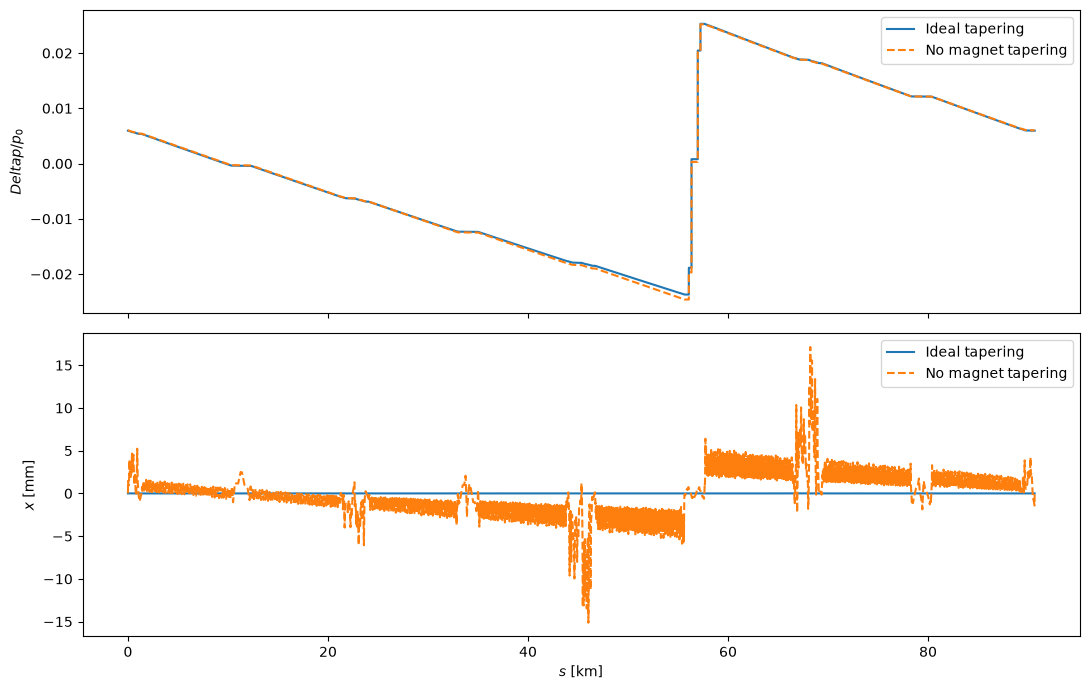

In [11]:
tw_no_taper = line.twiss(eneloss_and_damping=True)


fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)

axes[0].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:blue",
    lw=1.5,
    label="Ideal tapering",
)

axes[0].plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

axes[0].set_ylabel(
    r"$Delta p/p_0$"
)

axes[0].legend()


axes[1].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:blue",
    lw=1.5,
    label="Ideal tapering",
)

axes[1].plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.x * 1e3,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

axes[1].set_xlabel(
    r"$s$ [km]"
)

axes[1].set_ylabel(
    r"$x$ [mm]"
)

axes[1].legend()

fig.tight_layout()
plt.show()




In [12]:
# use markers to split into regions
def split_lattice_regions(line):
    ips = ["ipa", "ipb", "ipd", "ipf", "ipg", "iph", "ipj", "ipl"]

    table = line.get_table()
    names = np.asarray(table.name, dtype=str)
    s = np.asarray(table.s, dtype=float)

    valid = names != "_end_point"
    names = names[valid]
    s = s[valid]

    s_by_name = dict(zip(names, s))

    def select(start_marker, end_marker):
        start = s_by_name[start_marker]
        end = s_by_name[end_marker]

        if start <= end:
            mask = (s >= start) & (s < end)
        else:
            mask = (s >= start) | (s < end)

        return names[mask]

    arcs = {}
    arc_ds = {}
    ds = {}
    insertions = {}

    for i, left_ip in enumerate(ips):
        right_ip = ips[(i + 1) % len(ips)]
        sector = f"{left_ip}_{right_ip}"

        arcs[sector] = select(
            f"end_ds_start_arc_{left_ip}",
            f"end_arc_start_ds_{right_ip}",
        )

        arc_ds[sector] = select(
            f"end_straight_start_ds_{left_ip}",
            f"end_ds_start_straight_{right_ip}",
        )

        right_ds = select(
            f"end_straight_start_ds_{left_ip}",
            f"end_ds_start_arc_{left_ip}",
        )

        left_ds = select(
            f"end_arc_start_ds_{right_ip}",
            f"end_ds_start_straight_{right_ip}",
        )

        ds[sector] = np.concatenate([right_ds, left_ds])

        insertions[right_ip] = select(
            f"end_ds_start_straight_{right_ip}",
            f"end_straight_start_ds_{right_ip}",
        )

    return {
        "arcs": arcs,
        "arc_ds": arc_ds,
        "ds": ds,
        "insertions": insertions,
    }

regions = split_lattice_regions(line)
regions


{'arcs': {'ipa_ipb': array(['bpm_qd1am.0', 'end_ds_start_arc_ipa', 'qd1am.0', ...,
         '||drift_30::323', 'bpm_qd1am.50', 'qd1am.50'],
        shape=(3053,), dtype='<U25'),
  'ipb_ipd': array(['end_ds_start_arc_ipb', 'qd1am.52', 'bpm_qd1am.52', ...,
         'mbd.1634', '||drift_36::287', 'qd1am.102'],
        shape=(3052,), dtype='<U25'),
  'ipd_ipf': array(['bpm_qd1am.104', 'end_ds_start_arc_ipd', 'qd1am.104', ...,
         '||drift_36::938', 'bpm_qd1am.154', 'qd1am.154'],
        shape=(3053,), dtype='<U25'),
  'ipf_ipg': array(['end_ds_start_arc_ipf', 'qd1am.156', 'bpm_qd1am.156', ...,
         'mbd.3314', '||drift_36::1473', 'qd1am.206'],
        shape=(3052,), dtype='<U25'),
  'ipg_iph': array(['bpm_qd1am.208', 'end_ds_start_arc_ipg', 'qd1am.208', ...,
         '||drift_36::2118', 'bpm_qd1am.258', 'qd1am.258'],
        shape=(3053,), dtype='<U25'),
  'iph_ipj': array(['end_ds_start_arc_iph', 'qd1am.260', 'bpm_qd1am.260', ...,
         'mbd.4934', '||drift_89::9', 'qd1am.310'

# Step 1: set insertions to perfect tapering

In [13]:
clear_delta_taper(line, elements_with_taper)

# make it flat for all inserions
insertion_element_names_flat = np.concatenate(list(regions["insertions"].values()))

# filter only the elements that have tapering
insertion_mask = np.isin(elements_with_taper,insertion_element_names_flat)

insertion_elements_with_taper = elements_with_taper[insertion_mask]
insertion_ideal_delta_taper = ideal_delta_taper[insertion_mask]

restore_ideal_tapering(line, insertion_elements_with_taper, insertion_ideal_delta_taper)
# get_rf_phase(line, delta0='zero_mean', rtol_eneloss=1e-12, max_iter=100, verbose=True, co_search_at=None)
get_rf_phase(line)
rf_phase_insertions = read_rf_phase(line)

print(f"Restored ideal tapering for " f"{len(insertion_elements_with_taper)} insertion elements.")
rf_phase_insertions

/eos/home-d/ddomange/Documents/FCCeeCircuitCriticality/FCCee_tapering/tapering.py:115: RuntimeWarning: RF near its limit (get_rf_phase iteration 0): sin(phase_s) = 0.9066, phase_s = 65.04 deg, 9.3% headroom to crest.
  inst_phase = np.arcsin(_check_rf_headroom(egain / v0, context, rf_warn_ratio))


Restored ideal tapering for 1587 insertion elements.


/eos/home-d/ddomange/Documents/FCCeeCircuitCriticality/FCCee_tapering/tapering.py:115: RuntimeWarning: RF near its limit (get_rf_phase iteration 1): sin(phase_s) = 0.9066, phase_s = 65.04 deg, 9.3% headroom to crest.
  inst_phase = np.arcsin(_check_rf_headroom(egain / v0, context, rf_warn_ratio))


,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.119203,-64.125604
1,rf800.0,4020.0,-1.135224,-65.043531
2,rf800.1,4020.0,-1.135224,-65.043531
3,rf400.1,990.0,-1.119203,-64.125604


/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/twiss/twiss_defaults_and_input_preparation.py:501: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Text(0, 0.5, '$x$ [mm]')

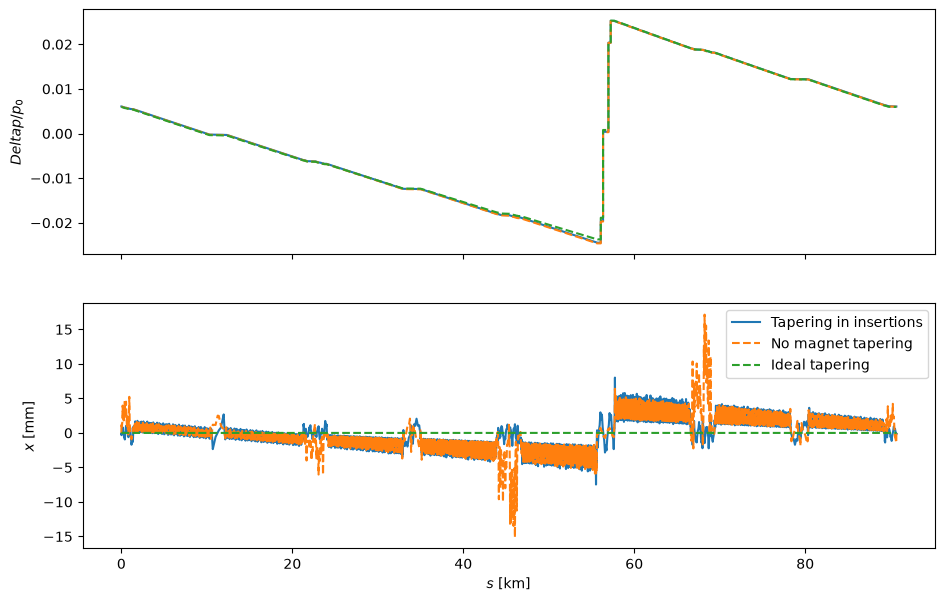

In [14]:
# twiss and plot orbit
twiss_insertion_taper = line.twiss(eneloss_and_damping=True)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)
plt.sca(axes[0])
plt.plot(
    twiss_insertion_taper.s / 1e3,
    twiss_insertion_taper.delta,
    color="tab:blue",
    lw=1.5,
    label="Tapering in insertions",
)
plt.plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

plt.plot(
    
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.ylabel(r"$Delta p/p_0$")
plt.sca(axes[1])
plt.plot(
    twiss_insertion_taper.s / 1e3,
    twiss_insertion_taper.x * 1e3,
    color="tab:blue",
    lw=1.5,
    label="Tapering in insertions",
)
plt.plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.x * 1e3,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)
plt.plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.legend()
plt.xlabel(r"$s$ [km]")
plt.ylabel(r"$x$ [mm]")

# Define circuits

In [15]:
# Define the number of tapering circuits for dipoles per sector. It should be a multiple of 3 or smaller than 3 to avoid separating consecutive dipoles in different circuits.
N_DIPOLE_CIRCUITS_PER_SECTOR = 1

In [16]:
import re
import numpy as np
import pandas as pd


def define_arc_circuits(line, regions, n_dipole_circuits_per_sector=1):
    table = line.get_table()

    type_by_name = dict(
        zip(
            np.asarray(table.name, dtype=str),
            np.asarray(table.element_type, dtype=str),
        )
    )

    taperable = {
        name
        for name in line.element_names
        if hasattr(line[name], "delta_taper")
    }

    def family(name):
        # qf2a.15 -> qf2a
        # sf1a.32 -> sf1a
        return re.sub(r"\.\d+$", "", name.lower())

    def select(elements, element_type=None, prefix=None):
        selected = []

        for name in elements:
            if name not in taperable:
                continue

            if element_type is not None:
                if element_type not in type_by_name.get(name, ""):
                    continue

            if prefix is not None:
                prefixes = (
                    (prefix,)
                    if isinstance(prefix, str)
                    else tuple(prefix)
                )

                if not family(name).startswith(prefixes):
                    continue

            selected.append(name)

        return np.asarray(selected, dtype=str)

    def split_in_two(elements):
        """
        Split an ordered family into two contiguous circuits.

        The first circuit contains the first half of the magnets along s.
        The second circuit contains the remaining magnets.
        """
        elements = np.asarray(elements, dtype=str)

        first, second = np.array_split(elements, 2)

        return first, second
    
    def split_in_n(elements, n):
            """
            Split an ordered family into n contiguous circuits.
    
            The first circuit contains the first m/n magnets along s.
            The second circuit contains the next m/n magnets.
            etc. The last circuit contains the remaining magnets.
            """
            elements = np.asarray(elements, dtype=str)
    
            split_elements = np.array_split(elements, n)
    
            return split_elements

    circuits = {}

    for sector in regions["arcs"]:

        arc_elements = regions["arcs"][sector]
        arc_ds_elements = regions["arc_ds"][sector]
        
        # --------------------------------------------------------------
        # Dipoles
        # 
        # Can't use the original circuits because of the twin aperture.
        # New circuits with different granularity are defined here.
        # 
        # Circuit names: DIP_1, DIP_2, ..., DIP_n
        # --------------------------------------------------------------

        dipole_elements = select(
            arc_ds_elements,
            element_type="Bend",
        )
        
        dipoles_circuits = split_in_n(dipole_elements, n_dipole_circuits_per_sector)
        for i, dipole_circuit in enumerate(dipoles_circuits):
            circuits[f"DIP_{i+1}_{sector}"] = dipole_circuit

        # --------------------------------------------------------------
        # Quadrupoles
        #
        # Original circuits:
        #   QF, QD
        #
        # New circuits:
        #   QF_1, QF_2, QD_1, QD_2
        # --------------------------------------------------------------

        qf_elements = select(
            arc_ds_elements,
            element_type="Quadrupole",
            prefix=("qf2a", "qf3a"),
        )

        qd_elements = select(
            arc_ds_elements,
            element_type="Quadrupole",
            prefix="qd1a", # qd1a and qd1am
        )

        qf_1, qf_2 = split_in_two(qf_elements)
        qd_1, qd_2 = split_in_two(qd_elements)

        circuits[f"QF_1_{sector}"] = qf_1
        circuits[f"QF_2_{sector}"] = qf_2
        circuits[f"QD_1_{sector}"] = qd_1
        circuits[f"QD_2_{sector}"] = qd_2

        # --------------------------------------------------------------
        # Sextupoles
        #
        # Original circuits:
        #   SF1, SF2, SD1, SD2
        #
        # Each family is one circuit per arc.
        # --------------------------------------------------------------

        sextupole_families = {
            "SF1": "sf1a",
            "SF2": "sf2a",
            "SD1": "sd1a",
            "SD2": "sd2a",
        }

        for circuit_family, prefix in sextupole_families.items():

            family_elements = select(
                arc_elements,
                element_type="Sextupole",
                prefix=prefix,
            )
            
            circuits[f"{circuit_family}_{sector}"] = family_elements

    # Remove empty circuits.
    circuits = {
        name: elements
        for name, elements in circuits.items()
        if len(elements) > 0
    }

    return circuits

In [17]:

circuits = define_arc_circuits(line, regions, n_dipole_circuits_per_sector=N_DIPOLE_CIRCUITS_PER_SECTOR)

summary = pd.DataFrame([
    {
        "circuit": circuit,
        "number_of_elements": len(elements),
        "first_element": elements[0],
        "last_element": elements[-1],
    }
    for circuit, elements in circuits.items()
])

display(summary)

,circuit,number_of_elements,first_element,last_element
0,DIP_1_ipa_ipb,840,mbd.0,mbd.839
1,QF_1_ipa_ipb,67,qf2a.0,qf3a.13
2,QF_2_ipa_ipb,66,qf2a.53,qf2a.105
3,QD_1_ipa_ipb,67,qd1a.0,qd1a.53
4,QD_2_ipa_ipb,67,qd1a.54,qd1a.107
...,...,...,...,...
67,QD_2_ipl_ipa,67,qd1a.810,qd1a.863
68,SF1_ipl_ipa,50,sf1a.358,sf1a.407
69,SF2_ipl_ipa,50,sf2a.358,sf2a.407
70,SD1_ipl_ipa,50,sd1a.358,sd1a.407


# Step 2: set dipoles in coarse granularity

In [18]:
def circuit_average_tapering_setters(line, circuits, dipole_tapering=True, quadrupole_tapering=True, sextupole_tapering=True):
    """
    Return a list of MultiSetter objects for the given circuits for average tapering.

    Each MultiSetter object can be used to set the delta_taper field
    for all magnets in a circuit simultaneously.
    """
    delta_taper_setters = []

    for circuit in circuits.keys():
        
        if circuit.startswith("DIP") and dipole_tapering:
            magnets = circuits[circuit]
            delta_taper_setters.append(
                xt.MultiSetter(line, magnets, field='delta_taper')
            )
        if circuit.startswith("Q") and quadrupole_tapering:
            magnets = circuits[circuit]
            delta_taper_setters.append(
                xt.MultiSetter(line, magnets, field='delta_taper')
            )
        if circuit.startswith("S") and sextupole_tapering:
            magnets = circuits[circuit]
            delta_taper_setters.append(
                xt.MultiSetter(line, magnets, field='delta_taper')
            )

    return delta_taper_setters

In [19]:
# Average tapering for dipoles only, quadrupoles and sextupoles are not tapered.
delta_taper_setters_mean = circuit_average_tapering_setters(line, 
                                                            circuits, 
                                                            dipole_tapering=True, 
                                                            quadrupole_tapering=False, 
                                                            sextupole_tapering=False)

delta_taper_setters_zero = circuit_average_tapering_setters(line,
                                                            circuits,
                                                            dipole_tapering=False,
                                                            quadrupole_tapering=True,
                                                            sextupole_tapering=True)

# No tapering in the correctors 
h_correctors_name = [name for name in elements_with_taper if name.startswith('hcor')]
v_correctors_name = [name for name in elements_with_taper if name.startswith('vcor')]


delta_taper_setters_zero.append(xt.MultiSetter(line, h_correctors_name, field='delta_taper'))
delta_taper_setters_zero.append(xt.MultiSetter(line, v_correctors_name, field='delta_taper'))

len(delta_taper_setters_mean), len(delta_taper_setters_zero)

(8, 66)

In [20]:
# Realisitic tapering with energy loss compensation
MAX_ITER = 10
TOLERANCE = 1e-9
CAVITY_MIDPOINT = "qd18f.0"

co = compensate_energy_loss(
    line,
    delta_taper_setters_mean=delta_taper_setters_mean,
    delta_taper_setters_no_tapering= delta_taper_setters_zero,
    apply_full_taper=True, # Apply ideal tapering everywhere else than the elements set in the multi-setters
    cavity_midpoint= CAVITY_MIDPOINT,
    verbose=True,
    max_iter = MAX_ITER,
    tolerance= TOLERANCE
)

Initial starting point: ipa
Closed orbit search succeeded. Proceeding with compensation and tapering.
Iteration 0
Particles(q0=1, mass0=5.11e+05, p0c=[1.825e+11], gamma0=[357143.59099955], beta0=[1.], s=[0.], zeta=[-1.08897882e-09], x=[-0.00182832], y=[-3.97354937e-12], px=[1.14683706e-05], py=[-1.66056984e-13], ptau=[0.00038806], delta=[0.00038806], rpp=[0.99961209], rvv=[1.], chi=[1.], charge_ratio=[1.], weight=[1.], ax=[0.], ay=[0.], spin_x=[0.], spin_y=[0.], spin_z=[0.], anomalous_magnetic_moment=[0.], pdg_id=[-11], particle_id=[0], at_element=[0], at_turn=[0], state=[1], parent_particle_id=[0], start_tracking_at_element=np.int64(-1), t_sim=0.000302)
Energy loss (MeV): -9070.804709732869
Energy loss diff.: 0.04970303950558041
Iteration 1


/eos/home-d/ddomange/Documents/FCCeeCircuitCriticality/FCCee_tapering/tapering.py:115: RuntimeWarning: RF near its limit (tapering iteration 0): sin(phase_s) = 0.9066, phase_s = 65.04 deg, 9.3% headroom to crest.
  inst_phase = np.arcsin(_check_rf_headroom(egain / v0, context, rf_warn_ratio))


Particles(q0=1, mass0=5.11e+05, p0c=[1.825e+11], gamma0=[357143.59099955], beta0=[1.], s=[0.], zeta=[-0.00190771], x=[-6.36524966e-05], y=[1.75029069e-11], px=[1.10921689e-06], py=[7.4921732e-15], ptau=[0.00074192], delta=[0.00074192], rpp=[0.99925863], rvv=[1.], chi=[1.], charge_ratio=[1.], weight=[1.], ax=[0.], ay=[0.], spin_x=[0.], spin_y=[0.], spin_z=[0.], anomalous_magnetic_moment=[0.], pdg_id=[-11], particle_id=[0], at_element=[0], at_turn=[0], state=[1], parent_particle_id=[0], start_tracking_at_element=np.int64(-1), t_sim=0.000302)
Energy loss (MeV): -8944.287609467254
Energy loss diff.: 0.0006932443850197756
Iteration 2
Particles(q0=1, mass0=5.11e+05, p0c=[1.825e+11], gamma0=[357143.59099955], beta0=[1.], s=[0.], zeta=[-1.50312239e-06], x=[-7.47075184e-05], y=[1.50162219e-11], px=[1.20349384e-06], py=[2.2989578e-13], ptau=[0.00073782], delta=[0.00073782], rpp=[0.99926273], rvv=[1.], chi=[1.], charge_ratio=[1.], weight=[1.], ax=[0.], ay=[0.], spin_x=[0.], spin_y=[0.], spin_z=[0

In [21]:
def read_applied_tapering(line, circuits, circuit_prefixes, ideal_taper_by_name):
    applied_settings = []

    for circuit_name, circuit_elements in circuits.items():

        if not circuit_name.startswith(tuple(circuit_prefixes)):
            continue

        elements = [
            name for name in circuit_elements
            if name in ideal_taper_by_name
        ]

        if len(elements) == 0:
            continue

        applied_values = np.asarray(
            [float(line[name].delta_taper) for name in elements],
            dtype=float,
        )

        ideal_values = np.asarray(
            [ideal_taper_by_name[name] for name in elements],
            dtype=float,
        )

        applied_settings.append({
            "circuit": circuit_name,
            "number_of_elements": len(elements),
            "applied_delta_taper": np.mean(applied_values),
            "ideal_min": np.min(ideal_values),
            "ideal_max": np.max(ideal_values),
            "maximum_error": np.max(
                np.abs(ideal_values - applied_values)
            ),
        })

    return pd.DataFrame(applied_settings)

In [22]:
read_applied_tapering(line, circuits, ["DIP"], ideal_taper_by_name)

,circuit,number_of_elements,applied_delta_taper,ideal_min,ideal_max,maximum_error
0,DIP_1_ipa_ipb,840,0.002429,-0.000367,0.005360,0.002931
1,DIP_1_ipb_ipd,840,-0.003305,-0.006037,-0.000440,0.002865
2,DIP_1_ipd_ipf,840,-0.009673,-0.012334,-0.006879,0.002794
3,DIP_1_ipf_ipg,840,-0.015095,-0.017698,-0.012361,0.002734
4,DIP_1_ipg_iph,840,-0.021169,-0.023708,-0.018501,0.002668
5,DIP_1_iph_ipj,840,0.022133,0.019107,0.025289,0.003156
6,DIP_1_ipj_ipl,840,0.015098,0.012155,0.018177,0.003079
7,DIP_1_ipl_ipa,840,0.009117,0.006244,0.012125,0.003009


/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/twiss/twiss_defaults_and_input_preparation.py:501: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Text(0, 0.5, '$x$ [mm]')

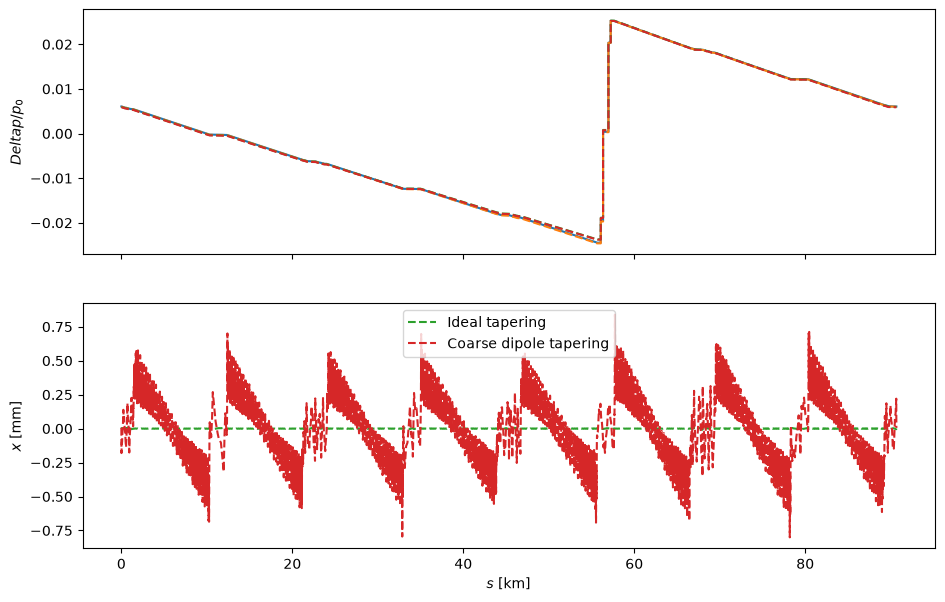

In [23]:
rf_phase_dipole = read_rf_phase(line)

# Twiss and plot orbit
twiss_dipole = line.twiss(eneloss_and_damping=True)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)
plt.sca(axes[0])
plt.plot(
    twiss_insertion_taper.s / 1e3,
    twiss_insertion_taper.delta,
    color="tab:blue",
    lw=1.5,
    label="Tapering in insertions",
)
plt.plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

plt.plot(
    
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.plot(
    twiss_dipole.s / 1e3,
    twiss_dipole.delta,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse dipole tapering",
)

plt.ylabel(r"$Delta p/p_0$")
plt.sca(axes[1])
#plt.plot(
#    twiss_insertion_taper.s / 1e3,
#    twiss_insertion_taper.x * 1e3,
#    color="tab:blue",
#    lw=1.5,
#    label="Tapering in insertions",
#)
#plt.plot(
#    tw_no_taper.s / 1e3,
#    tw_no_taper.x * 1e3,
#    color="tab:orange",
#    ls="--",
#    lw=1.5,
#    label="No magnet tapering",
#)
plt.plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.plot(
    twiss_dipole.s / 1e3,
    twiss_dipole.x * 1e3,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse dipole tapering",
)

plt.legend()
plt.xlabel(r"$s$ [km]")
plt.ylabel(r"$x$ [mm]")

# Step 3 set quad and sextupoles in coarse granularity

In [24]:
# Average tapering for dipoles only, quadrupoles and sextupoles are not tapered.
delta_taper_setters_mean = circuit_average_tapering_setters(line, 
                                                            circuits, 
                                                            dipole_tapering=True, 
                                                            quadrupole_tapering=True, 
                                                            sextupole_tapering=True)

delta_taper_setters_zero =[]

# No tapering in the correctors 
h_correctors_name = [name for name in elements_with_taper if name.startswith('hcor')]
v_correctors_name = [name for name in elements_with_taper if name.startswith('vcor')]


delta_taper_setters_zero.append(xt.MultiSetter(line, h_correctors_name, field='delta_taper'))
delta_taper_setters_zero.append(xt.MultiSetter(line, v_correctors_name, field='delta_taper'))

len(delta_taper_setters_mean), len(delta_taper_setters_zero)

(72, 2)

In [25]:
# Realisitic tapering with energy loss compensation
MAX_ITER = 10
TOLERANCE = 1e-9
CAVITY_MIDPOINT = "qd18f.0"

co = compensate_energy_loss(
    line,
    delta_taper_setters_mean=delta_taper_setters_mean,
    delta_taper_setters_no_tapering= delta_taper_setters_zero,
    apply_full_taper=True, # Apply ideal tapering everywhere else than the elements set in the multi-setters
    cavity_midpoint= CAVITY_MIDPOINT,
    verbose=True,
    max_iter = MAX_ITER,
    tolerance= TOLERANCE
)

Initial starting point: ipa
Closed orbit search succeeded. Proceeding with compensation and tapering.
Iteration 0
Particles(q0=1, mass0=5.11e+05, p0c=[1.825e+11], gamma0=[357143.59099955], beta0=[1.], s=[0.], zeta=[-4.3565626e-07], x=[-7.36218842e-05], y=[2.00019946e-13], px=[1.19594697e-06], py=[1.01770757e-15], ptau=[0.00073116], delta=[0.00073116], rpp=[0.99926938], rvv=[1.], chi=[1.], charge_ratio=[1.], weight=[1.], ax=[0.], ay=[0.], spin_x=[0.], spin_y=[0.], spin_z=[0.], anomalous_magnetic_moment=[0.], pdg_id=[-11], particle_id=[0], at_element=[0], at_turn=[0], state=[1], parent_particle_id=[0], start_tracking_at_element=np.int64(-1), t_sim=0.000302)
Energy loss (MeV): -8943.945330898416
Energy loss diff.: 0.04900791962155329
Iteration 1
Particles(q0=1, mass0=5.11e+05, p0c=[1.825e+11], gamma0=[357143.59099955], beta0=[1.], s=[0.], zeta=[1.00746834e-06], x=[-0.00011609], y=[-5.40848563e-13], px=[1.5629849e-06], py=[-7.1180306e-15], ptau=[0.00073322], delta=[0.00073322], rpp=[0.9992

In [26]:
# Quadrupoles tapering
read_applied_tapering(line, circuits, [ "QF", "QD"], ideal_taper_by_name)

,circuit,number_of_elements,applied_delta_taper,ideal_min,ideal_max,maximum_error
0,QF_1_ipa_ipb,67,0.003799,0.002480,0.005198,0.001399
1,QF_2_ipa_ipb,66,0.001075,-0.000209,0.002439,0.001364
2,QD_1_ipa_ipb,67,0.003819,0.002500,0.005218,0.001399
3,QD_2_ipa_ipb,67,0.001075,-0.000229,0.002459,0.001384
4,QF_1_ipb_ipd,67,-0.001967,-0.003254,-0.000598,0.001368
5,QF_2_ipb_ipd,66,-0.004628,-0.005882,-0.003294,0.001334
6,QD_1_ipb_ipd,67,-0.001947,-0.003234,-0.000578,0.001368
7,QD_2_ipb_ipd,67,-0.004628,-0.005902,-0.003274,0.001354
8,QF_1_ipd_ipf,67,-0.008368,-0.009622,-0.007033,0.001335
9,QF_2_ipd_ipf,66,-0.010962,-0.012183,-0.009661,0.001302


In [27]:
# Sextupoles tapering
read_applied_tapering(line, circuits, [ "SF", "SD"], ideal_taper_by_name)

,circuit,number_of_elements,applied_delta_taper,ideal_min,ideal_max,maximum_error
0,SF1_ipa_ipb,50,0.002447,-0.000006,0.004991,0.002544
1,SF2_ipa_ipb,50,0.002447,-0.000046,0.005032,0.002585
2,SD1_ipa_ipb,50,0.002447,-0.000026,0.005011,0.002564
3,SD2_ipa_ipb,50,0.002447,0.000014,0.004970,0.002523
4,SF1_ipb_ipd,50,-0.003288,-0.005684,-0.000801,0.002487
5,SF2_ipb_ipd,50,-0.003288,-0.005723,-0.000760,0.002528
6,SD1_ipb_ipd,50,-0.003288,-0.005704,-0.000780,0.002507
7,SD2_ipb_ipd,50,-0.003288,-0.005664,-0.000821,0.002467
8,SF1_ipd_ipf,50,-0.009656,-0.011990,-0.007230,0.002425
9,SF2_ipd_ipf,50,-0.009656,-0.012029,-0.007191,0.002465


In [28]:
rf_phase_quad_sext = read_rf_phase(line)

rf_phase_quad_sext

,name,voltage_MV,phase_taper_rad,phase_taper_deg
0,rf400.0,990.0,-1.103220,-63.209845
1,rf800.0,4020.0,-1.103258,-63.212013
2,rf800.1,4020.0,-1.103258,-63.212013
3,rf400.1,990.0,-1.103220,-63.209845


/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/twiss/twiss_defaults_and_input_preparation.py:501: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


Text(0, 0.5, '$x$ [mm]')

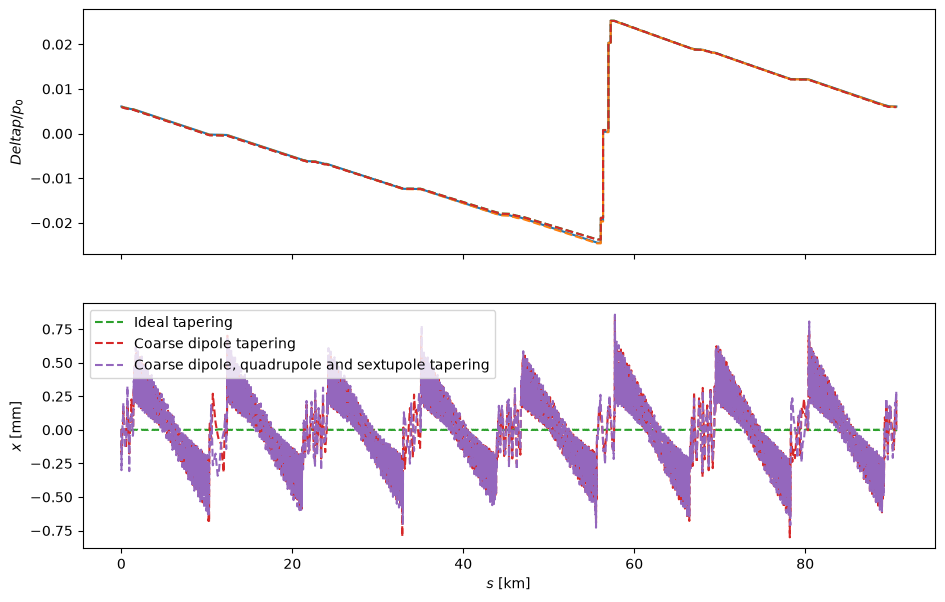

In [29]:
# twiss and plot orbit
twiss_quad_sext = line.twiss(eneloss_and_damping=True, radiation_analysis=True)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
)
plt.sca(axes[0])
plt.plot(
    twiss_insertion_taper.s / 1e3,
    twiss_insertion_taper.delta,
    color="tab:blue",
    lw=1.5,
    label="Tapering in insertions",
)
plt.plot(
    tw_no_taper.s / 1e3,
    tw_no_taper.delta,
    color="tab:orange",
    ls="--",
    lw=1.5,
    label="No magnet tapering",
)

plt.plot(
    
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

plt.plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.delta,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse quadrupole and sextupole tapering",
)

plt.ylabel(r"$Delta p/p_0$")
plt.sca(axes[1])

plt.plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    ls="--",
    lw=1.5,
    label="Ideal tapering",
)

# dipoles
plt.plot(
    twiss_dipole.s / 1e3,
    twiss_dipole.x * 1e3,
    color="tab:red",
    ls="--",
    lw=1.5,
    label="Coarse dipole tapering",
)

plt.plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.x * 1e3,
    color="tab:purple",
    ls="--",
    lw=1.5,
    label="Coarse dipole, quadrupole and sextupole tapering",
)

plt.legend()
plt.xlabel(r"$s$ [km]")
plt.ylabel(r"$x$ [mm]")

# Step 4: correct the horizontal orbit with one dipole trim per arc+DS cell

In [30]:
twiss_ideal["length"]

array([0. , 0. , 2.4, ..., 2.4, 0. , 0. ], shape=(30053,))

In [31]:
from scipy.sparse.linalg import lsmr


def dipoles_in_region(line, element_names):
    # first step isolate the dipoles in each arc
    table = line.get_table()
    type_by_name = dict(zip(np.asarray(table.name, dtype=str),np.asarray(table.element_type, dtype=str)))

    return np.asarray([
        str(name) for name in element_names
        if "Bend" in type_by_name.get(str(name), "")
    ], dtype=str)


def select_first_dipole_of_each_cell(line, regions):
    table = line.get_table()
    tw = line.twiss(eneloss_and_damping=True)
    s_by_name = dict(zip(
        np.asarray(table.name, dtype=str),
        np.asarray(table.s, dtype=float),
    ))
    length_by_name = dict(zip(
        np.asarray(tw.name, dtype=str),
        np.asarray(tw.length, dtype=float),
    ))

    selected = []
    rows = []
    # i keep dipoles also in the DS
    for sector, arc_ds_elements in regions["arc_ds"].items():
        dipoles = dipoles_in_region(line, arc_ds_elements)

        if len(dipoles) % 3 != 0:
            raise ValueError(
                f"{sector} contains {len(dipoles)} dipoles; "
                "the number is not divisible by three."
            )

        dipole_triplets = dipoles.reshape(-1, 3)

        for cell_number, triplet in enumerate(dipole_triplets):
            trim_dipole = str(triplet[0])
            selected.append(trim_dipole)
            rows.append({
                "sector": sector,
                "cell": cell_number,
                "trim_dipole": trim_dipole,
                "second_dipole": str(triplet[1]),
                "third_dipole": str(triplet[2]),
                "s_km": s_by_name[trim_dipole] / 1e3,
                "length_m": length_by_name[trim_dipole]
            })

    return np.asarray(selected, dtype=str), pd.DataFrame(rows)


def validate_first_dipole_selection(line, regions, trim_dipole_names, trim_layout):
    expected = []
    sector_rows = []

    for sector, arc_ds_elements in regions["arc_ds"].items():
        dipoles = dipoles_in_region(line, arc_ds_elements)
        assert len(dipoles) % 3 == 0

        expected_sector = dipoles[::3]
        expected.extend(expected_sector)

        selected_sector = trim_layout.loc[
            trim_layout["sector"] == sector,
            "trim_dipole",
        ].to_numpy(dtype=str)

        sector_rows.append({
            "sector": sector,
            "dipoles_in_arc_ds": len(dipoles),
            "expected_trims": len(expected_sector),
            "selected_trims": len(selected_sector),
            "selection_is_correct": np.array_equal(
                selected_sector,
                expected_sector,
            ),
        })

    expected = np.asarray(expected, dtype=str)
    selected = np.asarray(trim_dipole_names, dtype=str)

    assert len(selected) == len(np.unique(selected)), "Duplicate trim dipoles found"
    assert np.array_equal(selected, expected), (
        "The selected list is not exactly every third dipole, beginning "
        "with the first dipole, in each arc+DS sector."
    )
    assert np.all(
        trim_layout["trim_dipole"].to_numpy(dtype=str)
        != trim_layout["second_dipole"].to_numpy(dtype=str)
    )
    assert np.all(
        trim_layout["trim_dipole"].to_numpy(dtype=str)
        != trim_layout["third_dipole"].to_numpy(dtype=str)
    )

    summary = pd.DataFrame(sector_rows)
    assert summary["selection_is_correct"].all()

    print(
        f"Validated {len(selected)} trims: exactly the first dipole of "
        f"{len(selected)} three-dipole cells in the arc+DS regions."
    )
    return summary


def set_horizontal_dipole_trim_kicks(
    line,
    dipole_names,
    base_knl,
    trim_kicks_rad,
):
    for dipole_name, base_value, kick in zip(
        dipole_names,
        base_knl,
        trim_kicks_rad,
    ):
        # A positive horizontal kick corresponds to a negative knl[0].
        line.element_refs[dipole_name].knl[0] = float(base_value - kick)


def prepare_horizontal_dipole_trims(line, dipole_names):
    base_knl = np.asarray([
        float(line[name].knl[0]) for name in dipole_names
    ], dtype=float)

    set_horizontal_dipole_trim_kicks(
        line,
        dipole_names,
        base_knl,
        np.zeros(len(dipole_names)),
    )
    return base_knl


def verify_horizontal_dipole_trims(
    line,
    dipole_names,
    base_knl,
    test_kick_rad=1e-9,
):
    test_kicks = np.full(len(dipole_names), test_kick_rad)
    set_horizontal_dipole_trim_kicks(
        line,
        dipole_names,
        base_knl,
        test_kicks,
    )

    installed_knl = np.asarray([
        float(line[name].knl[0]) for name in dipole_names
    ])
    expected_knl = base_knl - test_kicks

    # Restore zero trims before starting the correction.
    set_horizontal_dipole_trim_kicks(
        line,
        dipole_names,
        base_knl,
        np.zeros(len(dipole_names)),
    )

    if not np.allclose(installed_knl, expected_knl, rtol=1e-10, atol=1e-16):
        bad = np.flatnonzero(~np.isclose(
            installed_knl,
            expected_knl,
            rtol=1e-10,
            atol=1e-16,
        ))
        raise RuntimeError(
            f"{len(bad)} numerical dipole trims failed the knl[0] test. "
            f"First failed element: {dipole_names[bad[0]]}"
        )

    print(
        f"Verified {len(dipole_names)} numerical trims in knl[0]."
    )

In [32]:
# BPMs and one selected dipole trim per three-dipole cell in arc+DS.
tt_monitors = tt.rows['bpm.*']
monitor_names = np.asarray(tt_monitors.name, dtype=str)
monitor_s = np.asarray(tt_monitors.s, dtype=float)

In [33]:
trim_dipole_names, trim_layout = select_first_dipole_of_each_cell(
    line,
    regions,
)

selection_summary = validate_first_dipole_selection(
    line,
    regions,
    trim_dipole_names,
    trim_layout,
)

Validated 2240 trims: exactly the first dipole of 2240 three-dipole cells in the arc+DS regions.


In [34]:
trim_base_knl = prepare_horizontal_dipole_trims(
    line,
    trim_dipole_names,
)
verify_horizontal_dipole_trims(
    line,
    trim_dipole_names,
    trim_base_knl,
)


Verified 2240 numerical trims in knl[0].


BPMs: 2636
Horizontal dipole trims: 2240


,sector,dipoles_in_arc_ds,expected_trims,selected_trims,selection_is_correct
0,ipa_ipb,840,280,280,True
1,ipb_ipd,840,280,280,True
2,ipd_ipf,840,280,280,True
3,ipf_ipg,840,280,280,True
4,ipg_iph,840,280,280,True
5,iph_ipj,840,280,280,True
6,ipj_ipl,840,280,280,True
7,ipl_ipa,840,280,280,True


,sector,cell,trim_dipole,second_dipole,third_dipole,s_km,length_m
0,ipa_ipb,0,mbd.0,mbd.1,mbd.2,1.363667,9.613334
1,ipa_ipb,1,mbd.3,mbd.4,mbd.5,1.394737,9.613334
2,ipa_ipb,2,mbd.6,mbd.7,mbd.8,1.428962,9.613334
3,ipa_ipb,3,mbd.9,mbd.10,mbd.11,1.461062,9.613334
4,ipa_ipb,4,mbd.12,mbd.13,mbd.14,1.495687,9.613334
5,ipa_ipb,5,mbd.15,mbd.16,mbd.17,1.526757,9.613334
6,ipa_ipb,6,mbd.18,mbd.19,mbd.20,1.559257,9.613334
7,ipa_ipb,7,mbd.21,mbd.22,mbd.23,1.590947,9.613334
8,ipa_ipb,8,mbd.24,mbd.25,mbd.26,1.623447,9.613334
9,ipa_ipb,9,mbd.27,mbd.28,mbd.29,1.655137,9.613334


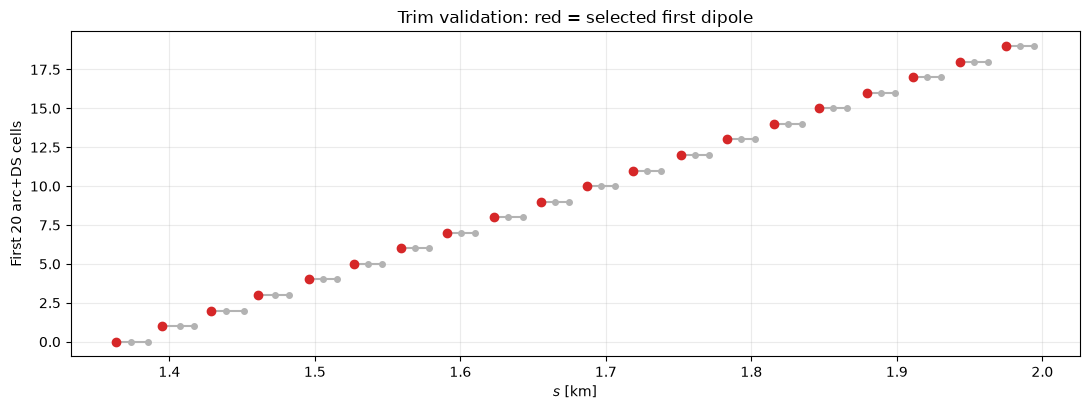

In [35]:





print(f"BPMs: {len(monitor_names)}")
print(f"Horizontal dipole trims: {len(trim_dipole_names)}")
display(selection_summary)
display(trim_layout.head(12))

# Visual check: within every row, the red point must be the first of the
# three ordered dipoles shown in grey.
check_rows = trim_layout.iloc[:20]
fig, ax = plt.subplots(figsize=(11, 4.2))
for row_number, row in enumerate(check_rows.itertuples(index=False)):
    names = [row.trim_dipole, row.second_dipole, row.third_dipole]
    table_indices = tt.rows.indices[names]
    s_triplet = np.asarray(tt.s[table_indices], dtype=float) / 1e3
    ax.plot(s_triplet, np.full(3, row_number), 'o-', color='0.7', ms=4)
    ax.plot(s_triplet[0], row_number, 'o', color='tab:red', ms=6)

ax.set_xlabel(r'$s$ [km]')
ax.set_ylabel('First 20 arc+DS cells')
ax.set_title('Trim validation: red = selected first dipole')
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

In [36]:
def build_horizontal_response_matrix(twiss, monitor_names, trim_dipole_names):
    monitor_indices = twiss.rows.indices[list(monitor_names)]
    trim_indices = twiss.rows.indices[list(trim_dipole_names)]

    beta_monitor = np.asarray(twiss.betx[monitor_indices], dtype=float)
    beta_trim = np.asarray(twiss.betx[trim_indices], dtype=float)
    mu_monitor = np.asarray(twiss.mux[monitor_indices], dtype=float)
    mu_trim = np.asarray(twiss.mux[trim_indices], dtype=float)
    tune = float(twiss.qx)

    beta_product = beta_monitor[:, None] * beta_trim[None, :]
    phase_difference = np.abs(mu_monitor[:, None] - mu_trim[None, :])

    return (
        np.sqrt(beta_product)
        / (2.0 * np.sin(np.pi * tune))
        * np.cos(np.pi * tune - 2.0 * np.pi * phase_difference)
    )


def correct_horizontal_orbit_with_dipole_trims(
    line,
    reference,
    monitor_names,
    trim_dipole_names,
    trim_base_knl,
    tolerance_rms_m=1e-6,
    max_iterations=10,
    gain=1.0,
    regularization=1e-3,
    solver_max_iterations=400,
):
    response = build_horizontal_response_matrix(
        reference,
        monitor_names,
        trim_dipole_names,
    )

    # Normalize columns so the regularization treats all trim locations fairly.
    column_scale = np.linalg.norm(response, axis=0)
    column_scale[column_scale == 0.0] = 1.0
    response_scaled = response / column_scale[None, :]

    reference_indices = reference.rows.indices[list(monitor_names)]
    reference_x = np.asarray(reference.x[reference_indices], dtype=float)
    history = []
    total_trim_kicks = np.zeros(len(trim_dipole_names), dtype=float)

    for iteration in range(max_iterations + 1):
        twiss_orbit = line.twiss(only_orbit=True)
        orbit_indices = twiss_orbit.rows.indices[list(monitor_names)]
        residual = np.asarray(twiss_orbit.x[orbit_indices], dtype=float) - reference_x

        rms_residual = float(np.sqrt(np.mean(residual**2)))
        maximum_residual = float(np.max(np.abs(residual)))

        history.append({
            "iteration": iteration,
            "x_rms_m": rms_residual,
            "x_max_m": maximum_residual,
        })

        print(
            f"Iteration {iteration}: x RMS = {rms_residual * 1e6:.4f} um, "
            f"max = {maximum_residual * 1e6:.4f} um"
        )

        if rms_residual <= tolerance_rms_m:
            print("Horizontal orbit correction converged.")
            break

        if iteration == max_iterations:
            print("Maximum number of iterations reached.")
            break

        solution = lsmr(
            response_scaled,
            -residual,
            damp=regularization,
            atol=1e-11,
            btol=1e-11,
            maxiter=solver_max_iterations,
        )
        delta_kick = gain * solution[0] / column_scale

        total_trim_kicks += delta_kick
        set_horizontal_dipole_trim_kicks(
            line,
            trim_dipole_names,
            trim_base_knl,
            total_trim_kicks,
        )

        applied_kicks = total_trim_kicks
        print(
            f"  LSMR iterations = {solution[2]}, "
            f"linear residual norm = {solution[3] * 1e6:.4f} um, "
            f"step RMS = {1e6 * np.sqrt(np.mean(delta_kick**2)):.4f} urad, "
            f"total trim RMS = {1e6 * np.sqrt(np.mean(applied_kicks**2)):.4f} urad"
        )

    return pd.DataFrame(history), response, total_trim_kicks

In [37]:
trim_correction_history, trim_response_matrix, trim_kicks_rad = (
    correct_horizontal_orbit_with_dipole_trims(
        line=line,
        reference=twiss_ideal,
        monitor_names=monitor_names,
        trim_dipole_names=trim_dipole_names,
        trim_base_knl=trim_base_knl,
        tolerance_rms_m=1e-6,       # 1 um BPM RMS
        max_iterations=10,
        gain=1.0,
        regularization=1e-6,
        solver_max_iterations=400,
    )
)

display(trim_correction_history)

Iteration 0: x RMS = 232.4883 um, max = 856.8730 um
  LSMR iterations = 400, linear residual norm = 790.1923 um, step RMS = 5.3399 urad, total trim RMS = 5.3399 urad
Iteration 1: x RMS = 183.7162 um, max = 1361.8945 um
  LSMR iterations = 400, linear residual norm = 394.7851 um, step RMS = 0.5995 urad, total trim RMS = 4.8824 urad
Iteration 2: x RMS = 51.2753 um, max = 237.4274 um
  LSMR iterations = 400, linear residual norm = 261.1673 um, step RMS = 0.6903 urad, total trim RMS = 4.5641 urad
Iteration 3: x RMS = 69.7376 um, max = 355.4649 um
  LSMR iterations = 400, linear residual norm = 236.6530 um, step RMS = 0.3224 urad, total trim RMS = 4.4716 urad
Iteration 4: x RMS = 12.4261 um, max = 82.6919 um
  LSMR iterations = 400, linear residual norm = 204.0446 um, step RMS = 0.3806 urad, total trim RMS = 4.3526 urad
Iteration 5: x RMS = 14.0083 um, max = 92.6518 um
  LSMR iterations = 400, linear residual norm = 204.6728 um, step RMS = 0.1096 urad, total trim RMS = 4.3482 urad
Iteration

,iteration,x_rms_m,x_max_m
0,0,0.000232,0.000857
1,1,0.000184,0.001362
2,2,0.000051,0.000237
3,3,0.000070,0.000355
4,4,0.000012,0.000083
5,5,0.000014,0.000093
6,6,0.000005,0.000081
7,7,0.000005,0.000078
8,8,0.000004,0.000081
9,9,0.000004,0.000079


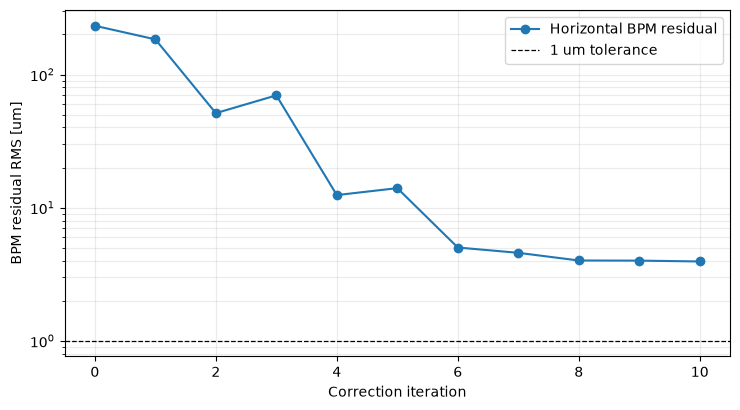

In [38]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.semilogy(
    trim_correction_history['iteration'],
    1e6 * trim_correction_history['x_rms_m'],
    'o-',
    label='Horizontal BPM residual',
)
ax.axhline(1.0, color='black', ls='--', lw=0.9, label='1 um tolerance')
ax.set_xlabel('Correction iteration')
ax.set_ylabel('BPM residual RMS [um]')
ax.grid(alpha=0.25, which='both')
ax.legend()
fig.tight_layout()
plt.show()

In [39]:
twiss_after_dipole_trims = line.twiss(
    eneloss_and_damping=True,
    radiation_analysis=True,
)

/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/twiss/twiss_defaults_and_input_preparation.py:501: FutureWarning: The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. 
Please use `radiation_analysis` instead, which has the same behavior. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('The `eneloss_and_damping` keyword is deprecated and will be removed in future versions. \n'


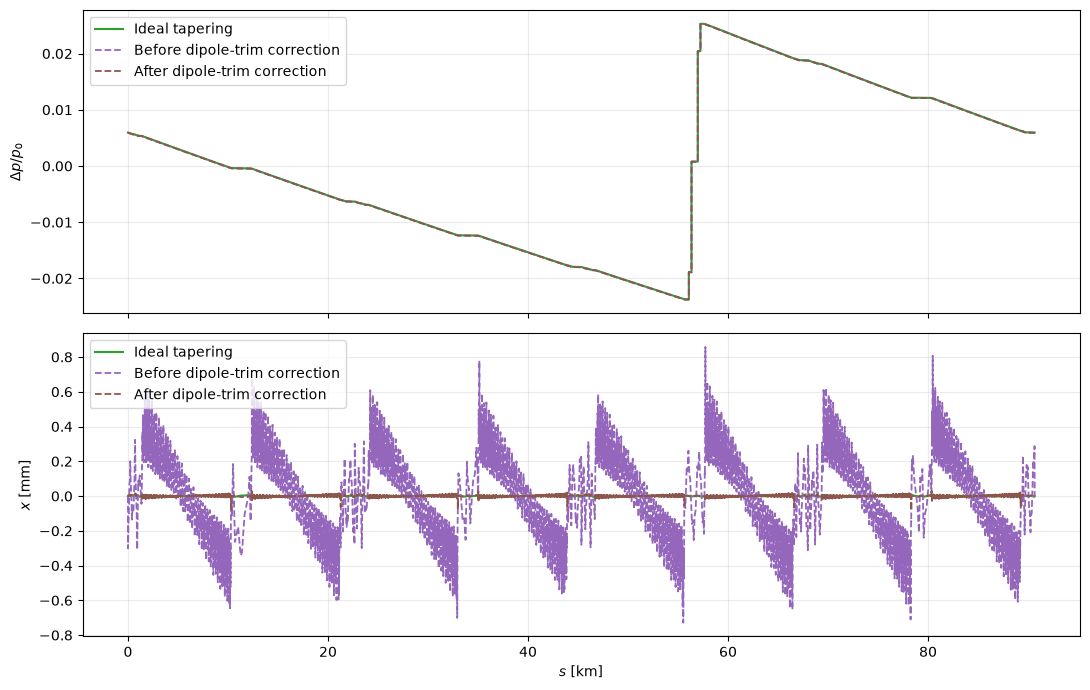

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.delta,
    color="tab:green",
    lw=1.5,
    label="Ideal tapering",
)
axes[0].plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.delta,
    color="tab:purple",
    ls="--",
    lw=1.3,
    label="Before dipole-trim correction",
)
axes[0].plot(
    twiss_after_dipole_trims.s / 1e3,
    twiss_after_dipole_trims.delta,
    color="tab:brown",
    ls="--",
    lw=1.3,
    label="After dipole-trim correction",
)
axes[0].set_ylabel(r"$\Delta p/p_0$")
axes[0].legend()

axes[1].plot(
    twiss_ideal.s / 1e3,
    twiss_ideal.x * 1e3,
    color="tab:green",
    lw=1.5,
    label="Ideal tapering",
)
axes[1].plot(
    twiss_quad_sext.s / 1e3,
    twiss_quad_sext.x * 1e3,
    color="tab:purple",
    ls="--",
    lw=1.3,
    label="Before dipole-trim correction",
)
axes[1].plot(
    twiss_after_dipole_trims.s / 1e3,
    twiss_after_dipole_trims.x * 1e3,
    color="tab:brown",
    ls="--",
    lw=1.3,
    label="After dipole-trim correction",
)
axes[1].set_xlabel(r"$s$ [km]")
axes[1].set_ylabel(r"$x$ [mm]")
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

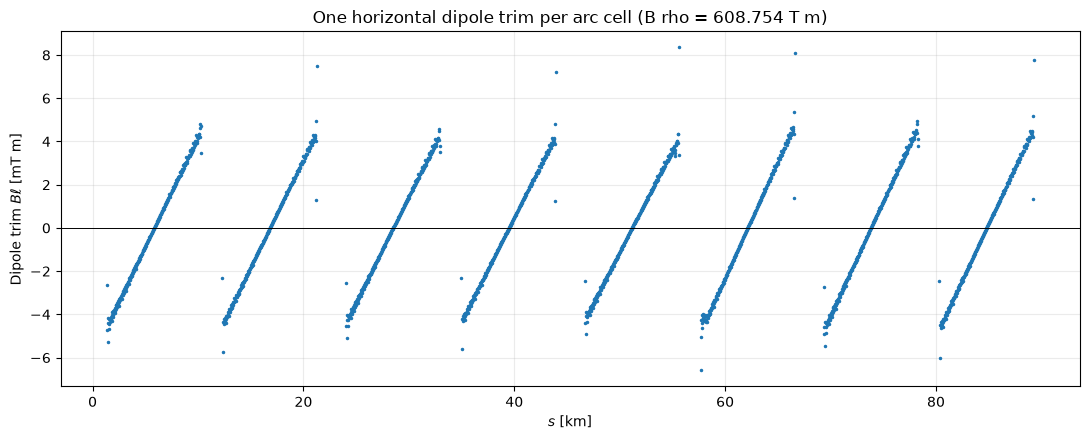

Trims: 2240
RMS kick = 4.30576 urad
Max |kick| = 13.715 urad
RMS |B*l| = 2.62115 mT m
Max |B*l| = 8.34909 mT m


In [41]:
p0c_GeV = float(line.particle_ref.p0c[0]) * 1e-9
charge_number = abs(float(line.particle_ref.q0))
magnetic_rigidity_Tm = p0c_GeV / (0.299792458 * charge_number)
trim_integrated_field_mTm = trim_kicks_rad * magnetic_rigidity_Tm * 1e3
trim_s_km = trim_layout['s_km'].to_numpy(float)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(trim_s_km, trim_integrated_field_mTm, '.', ms=3)
ax.axhline(0.0, color='black', lw=0.7)
ax.set_xlabel(r'$s$ [km]')
ax.set_ylabel(r'Dipole trim $B\ell$ [mT m]')
ax.grid(alpha=0.25)
ax.set_title(
    f'One horizontal dipole trim per arc cell '
    f'(B rho = {magnetic_rigidity_Tm:.3f} T m)'
)
fig.tight_layout()
plt.show()

print(f'Trims: {len(trim_kicks_rad)}')
print(f'RMS kick = {1e6 * np.sqrt(np.mean(trim_kicks_rad**2)):.6g} urad')
print(f'Max |kick| = {1e6 * np.max(np.abs(trim_kicks_rad)):.6g} urad')
print(f'RMS |B*l| = {np.sqrt(np.mean(trim_integrated_field_mTm**2)):.6g} mT m')
print(f'Max |B*l| = {np.max(np.abs(trim_integrated_field_mTm)):.6g} mT m')

In [42]:
twiss_scenario_2_before_correction = twiss_quad_sext
twiss_scenario_2_after_correction = twiss_after_dipole_trims

In [43]:
beta_beating_x = (
    twiss_scenario_2_after_correction.betx - twiss_ideal.betx
) / twiss_ideal.betx

beta_beating_y = (
    twiss_scenario_2_after_correction.bety - twiss_ideal.bety
) / twiss_ideal.bety


diagnostics = pd.DataFrame({
    "name": np.asarray(twiss_scenario_2_after_correction.name, dtype=str),
    "s_km": np.asarray(twiss_scenario_2_after_correction.s) / 1e3,
    "beta_beating_x": beta_beating_x,
    "beta_beating_y": beta_beating_y,
    "orbit_x_mm": (
        twiss_scenario_2_after_correction.x - twiss_ideal.x
    ) * 1e3,
})


print("Largest horizontal beta beating:")

display(
    diagnostics.iloc[
        np.argsort(np.abs(beta_beating_x))[-15:]
    ].sort_values(
        "beta_beating_x",
        key=np.abs,
        ascending=False,
    )
)


print("Largest vertical beta beating:")

display(
    diagnostics.iloc[
        np.argsort(np.abs(beta_beating_y))[-15:]
    ].sort_values(
        "beta_beating_y",
        key=np.abs,
        ascending=False,
    )
)

Largest horizontal beta beating:


,name,s_km,beta_beating_x,beta_beating_y,orbit_x_mm
20593,||drift_36::2438,62.245156,0.010984,0.001897,-0.000246
20594,qd1a.595,62.245306,0.010977,0.001878,-0.000253
28105,||drift_78::806,84.910220,0.010510,0.001318,0.000529
28106,qd1a.811,84.910370,0.010502,0.001299,0.000519
20595,||drift_34::893,62.247166,0.010494,0.001750,-0.000352
24555,qd1a.703,73.934770,0.010475,0.001361,-0.000143
24554,||drift_78::311,73.934620,0.010473,0.001377,-0.000137
20597,hcor_qd1a.595,62.247266,0.010448,0.001748,-0.000358
20596,bpm_qd1a.595,62.247266,0.010448,0.001748,-0.000358
20599,sd1a.281,62.247266,0.010448,0.001748,-0.000358


Largest vertical beta beating:


,name,s_km,beta_beating_x,beta_beating_y,orbit_x_mm
15065,||drift_36::1549,45.440468,0.001675,0.019646,0.001913
15066,qd4r.2,45.440618,0.001625,0.019008,0.001926
14920,b3l.3,44.776941,-0.003132,0.016075,0.002403
7553,||drift_36::366,22.775404,0.001642,0.015762,0.002046
7554,qd4r.1,22.775554,0.001590,0.015297,0.002052
14914,||drift_36::1531,44.775041,-0.003149,-0.014882,0.002422
14919,||drift_50::19,44.776791,-0.003133,0.014151,0.002408
14916,bpm_qy4l.2,44.776791,-0.003133,0.014151,0.002408
14918,vcor_qy4l.2,44.776791,-0.003133,0.014151,0.002408
14917,hcor_qy4l.2,44.776791,-0.003133,0.014151,0.002408


In [44]:
def twiss_scalar(twiss, *candidate_names):
    for name in candidate_names:
        value = getattr(twiss, name, None)
        if value is not None:
            array = np.asarray(value)
            if array.size:
                return float(array.reshape(-1)[0])
    return np.nan

def rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.nanmean(values**2)))

def max_abs(values):
    return float(np.nanmax(np.abs(np.asarray(values, dtype=float))))

def percent_change(value, reference):
    if not np.isfinite(reference) or reference == 0:
        return np.nan
    return 100.0 * (value/reference - 1.0)

def complete_optics_summary(twiss, reference):
    betx_beating = (twiss.betx-reference.betx)/reference.betx
    bety_beating = (twiss.bety-reference.bety)/reference.bety
    delta_x = twiss.x-reference.x
    delta_y = twiss.y-reference.y
    delta_dx = twiss.dx-reference.dx
    delta_dy = twiss.dy-reference.dy

    emit_x = twiss_scalar(twiss, 'eq_gemitt_x', 'rad_int_eq_gemitt_x')
    emit_y = twiss_scalar(twiss, 'eq_gemitt_y', 'rad_int_eq_gemitt_y')
    emit_x_ref = twiss_scalar(reference, 'eq_gemitt_x', 'rad_int_eq_gemitt_x')
    emit_y_ref = twiss_scalar(reference, 'eq_gemitt_y', 'rad_int_eq_gemitt_y')

    return {
        'Horizontal tune Qx': twiss_scalar(twiss, 'qx'),
        'Vertical tune Qy': twiss_scalar(twiss, 'qy'),
        'Horizontal tune shift': twiss_scalar(twiss, 'qx')-twiss_scalar(reference, 'qx'),
        'Vertical tune shift': twiss_scalar(twiss, 'qy')-twiss_scalar(reference, 'qy'),
        'Horizontal chromaticity Qx_prime': twiss_scalar(twiss, 'dqx'),
        'Vertical chromaticity Qy_prime': twiss_scalar(twiss, 'dqy'),
        'Minimum tune separation |C-|': twiss_scalar(twiss, 'c_minus'),
        'Synchrotron tune Qs': twiss_scalar(twiss, 'qs'),
        'RMS beta-x beating [%]': 100*rms(betx_beating),
        'Maximum beta-x beating [%]': 100*max_abs(betx_beating),
        'RMS beta-y beating [%]': 100*rms(bety_beating),
        'Maximum beta-y beating [%]': 100*max_abs(bety_beating),
        'RMS horizontal-orbit residual [um]': 1e6*rms(delta_x),
        'Maximum horizontal-orbit residual [um]': 1e6*max_abs(delta_x),
        'RMS vertical-orbit residual [um]': 1e6*rms(delta_y),
        'Maximum vertical-orbit residual [um]': 1e6*max_abs(delta_y),
        'RMS horizontal-dispersion residual [mm]': 1e3*rms(delta_dx),
        'Maximum horizontal-dispersion residual [mm]': 1e3*max_abs(delta_dx),
        'RMS vertical-dispersion residual [mm]': 1e3*rms(delta_dy),
        'Maximum vertical-dispersion residual [mm]': 1e3*max_abs(delta_dy),
        'Equilibrium horizontal emittance [nm]': 1e9*emit_x,
        'Horizontal emittance change [%]': percent_change(emit_x, emit_x_ref),
        'Equilibrium vertical emittance [pm]': 1e12*emit_y,
        'Vertical emittance change [%]': percent_change(emit_y, emit_y_ref),
        'Equilibrium longitudinal emittance [um]': 1e6*twiss_scalar(
            twiss, 'eq_gemitt_zeta', 'rad_int_eq_gemitt_zeta'),
        'Equilibrium momentum spread [%]': 100*twiss_scalar(
            twiss, 'eq_sigma_delta', 'rad_int_sigma_delta'),
        'Equilibrium bunch length [mm]': 1e3*twiss_scalar(
            twiss, 'eq_sigma_zeta', 'eq_sigma_z', 'rad_int_sigma_zeta'),
        'Energy loss per turn [GeV]': 1e-9*twiss_scalar(
            twiss, 'eneloss_turn', 'rad_int_energy_loss'),
        'Momentum compaction factor': twiss_scalar(
            twiss, 'momentum_compaction_factor'),
        'Slip factor': twiss_scalar(twiss, 'slip_factor'),
    }

optics_comparison = pd.DataFrame({
    'Ideal tapering': complete_optics_summary(twiss_ideal, twiss_ideal),
    'Scenario 2 before correction': complete_optics_summary(
        twiss_scenario_2_before_correction, twiss_ideal),
    'Scenario 2 after dipole-trim correction': complete_optics_summary(
        twiss_after_dipole_trims, twiss_ideal),
})
pd.set_option('display.max_rows', None)
display(optics_comparison)

/afs/cern.ch/work/d/ddomange/private/miniforge3/envs/fccee-tapering/lib/python3.13/site-packages/xtrack/table.py:317: FutureWarning: `eneloss_turn` is deprecated, use `energy_loss` instead. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn(depr_fields[name], FutureWarning)


,Ideal tapering,Scenario 2 before correction,Scenario 2 after dipole-trim correction
Horizontal tune Qx,3.461316e+02,3.461390e+02,3.461303e+02
Vertical tune Qy,2.622813e+02,2.622783e+02,2.622803e+02
Horizontal tune shift,0.000000e+00,7.428044e-03,-1.307132e-03
Vertical tune shift,0.000000e+00,-2.940671e-03,-9.584048e-04
Horizontal chromaticity Qx_prime,4.605619e+00,4.539207e+00,4.594629e+00
Vertical chromaticity Qy_prime,3.873637e+00,3.722595e+00,3.835198e+00
Minimum tune separation |C-|,1.672017e-10,2.621898e-10,1.364355e-10
Synchrotron tune Qs,9.183689e-02,9.182629e-02,9.186416e-02
RMS beta-x beating [%],0.000000e+00,2.327264e+00,3.502392e-01
Maximum beta-x beating [%],0.000000e+00,6.359286e+00,1.098352e+00


In [45]:
# Focused equilibrium-emittance comparison.
emittance_rows = [
    'Equilibrium horizontal emittance [nm]',
    'Horizontal emittance change [%]',
    'Equilibrium vertical emittance [pm]',
    'Vertical emittance change [%]',
    'Equilibrium momentum spread [%]',
    'Equilibrium bunch length [mm]',
]
display(optics_comparison.loc[emittance_rows])

,Ideal tapering,Scenario 2 before correction,Scenario 2 after dipole-trim correction
Equilibrium horizontal emittance [nm],2.189252,2.191262,2.189227
Horizontal emittance change [%],0.000000,0.091805,-0.001162
Equilibrium vertical emittance [pm],0.063790,0.063571,0.063875
Vertical emittance change [%],0.000000,-0.343111,0.132888
Equilibrium momentum spread [%],NaN,NaN,NaN
Equilibrium bunch length [mm],NaN,NaN,NaN


# Horizontal optics comparison for every case

The dispersion is compared directly with the ideal lattice. The beta beating is shown as the relative difference from the ideal horizontal beta function.

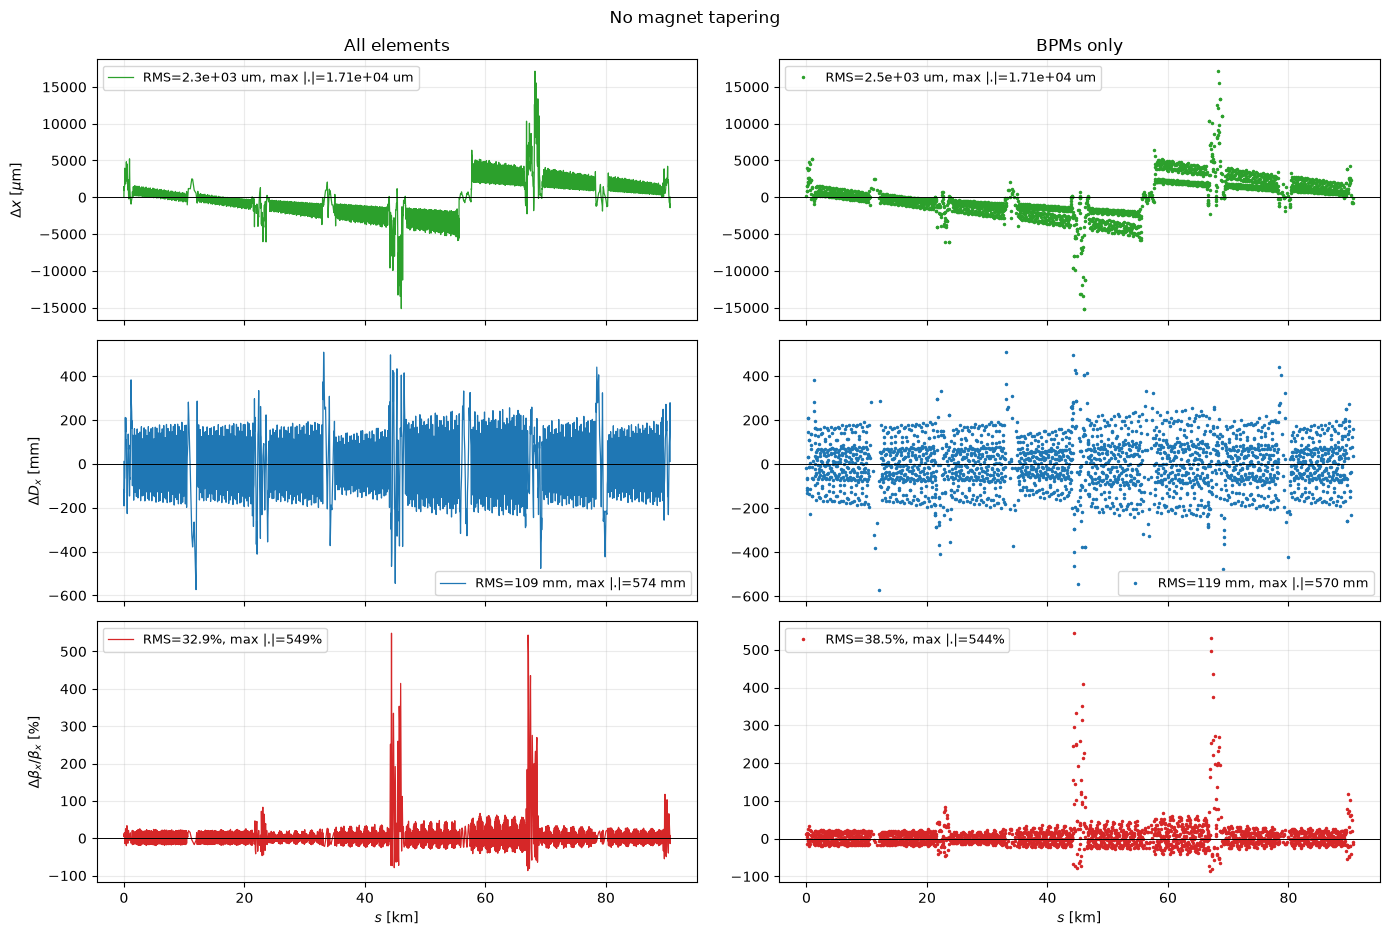

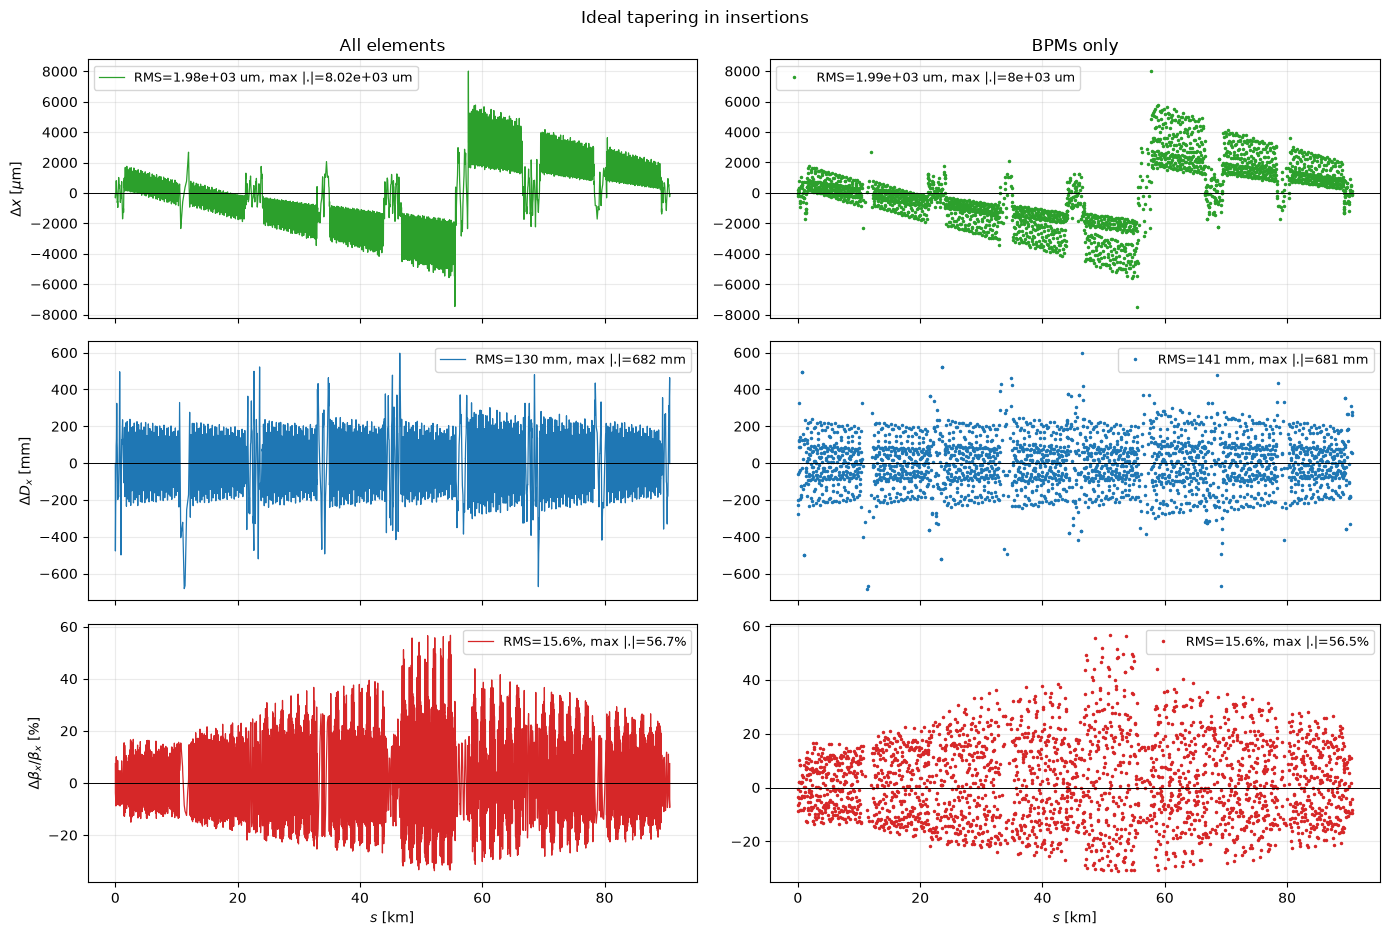

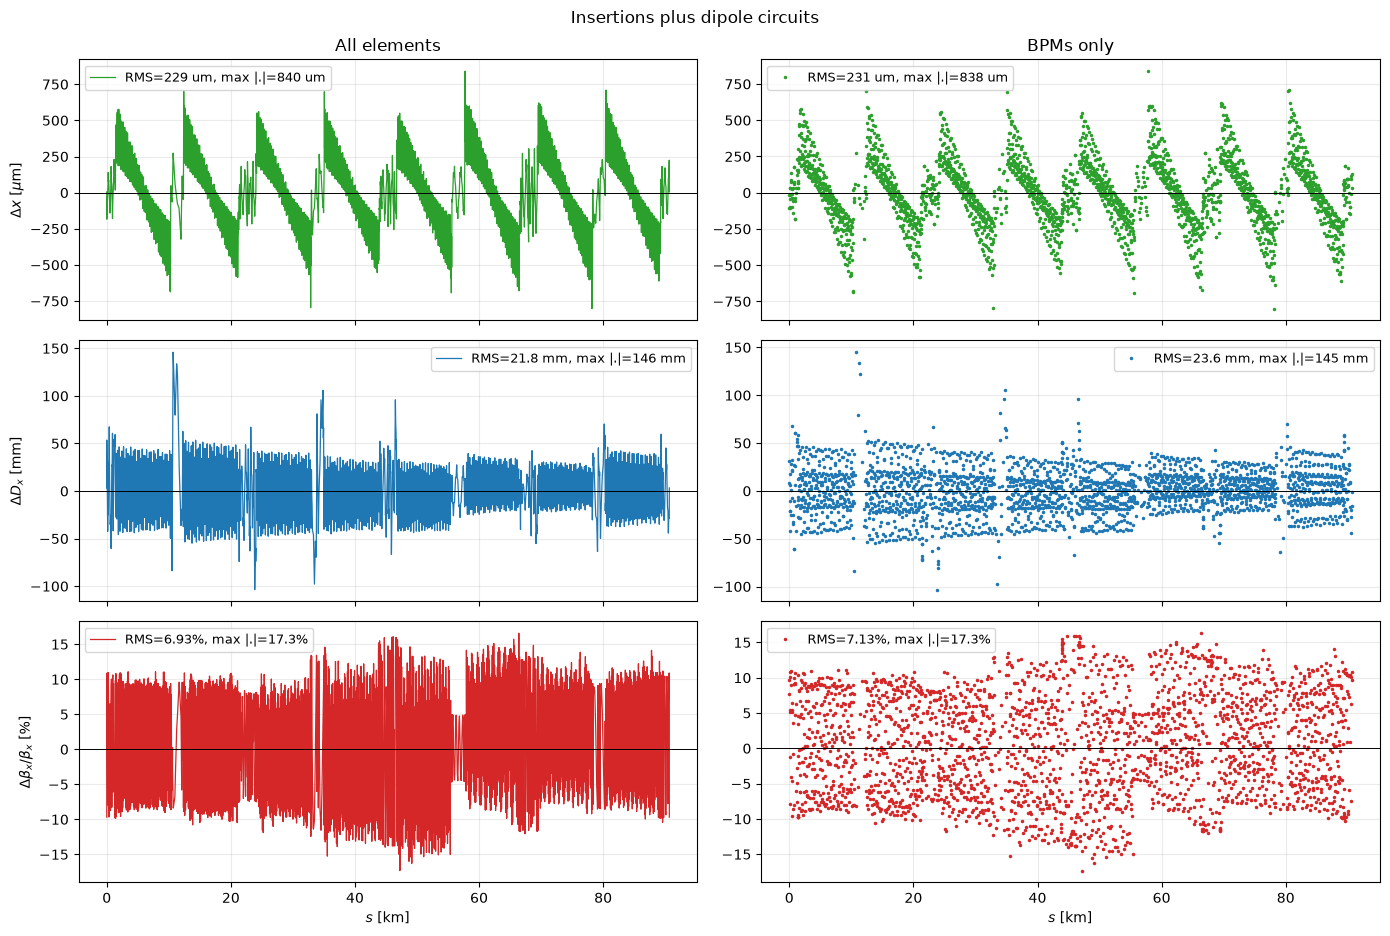

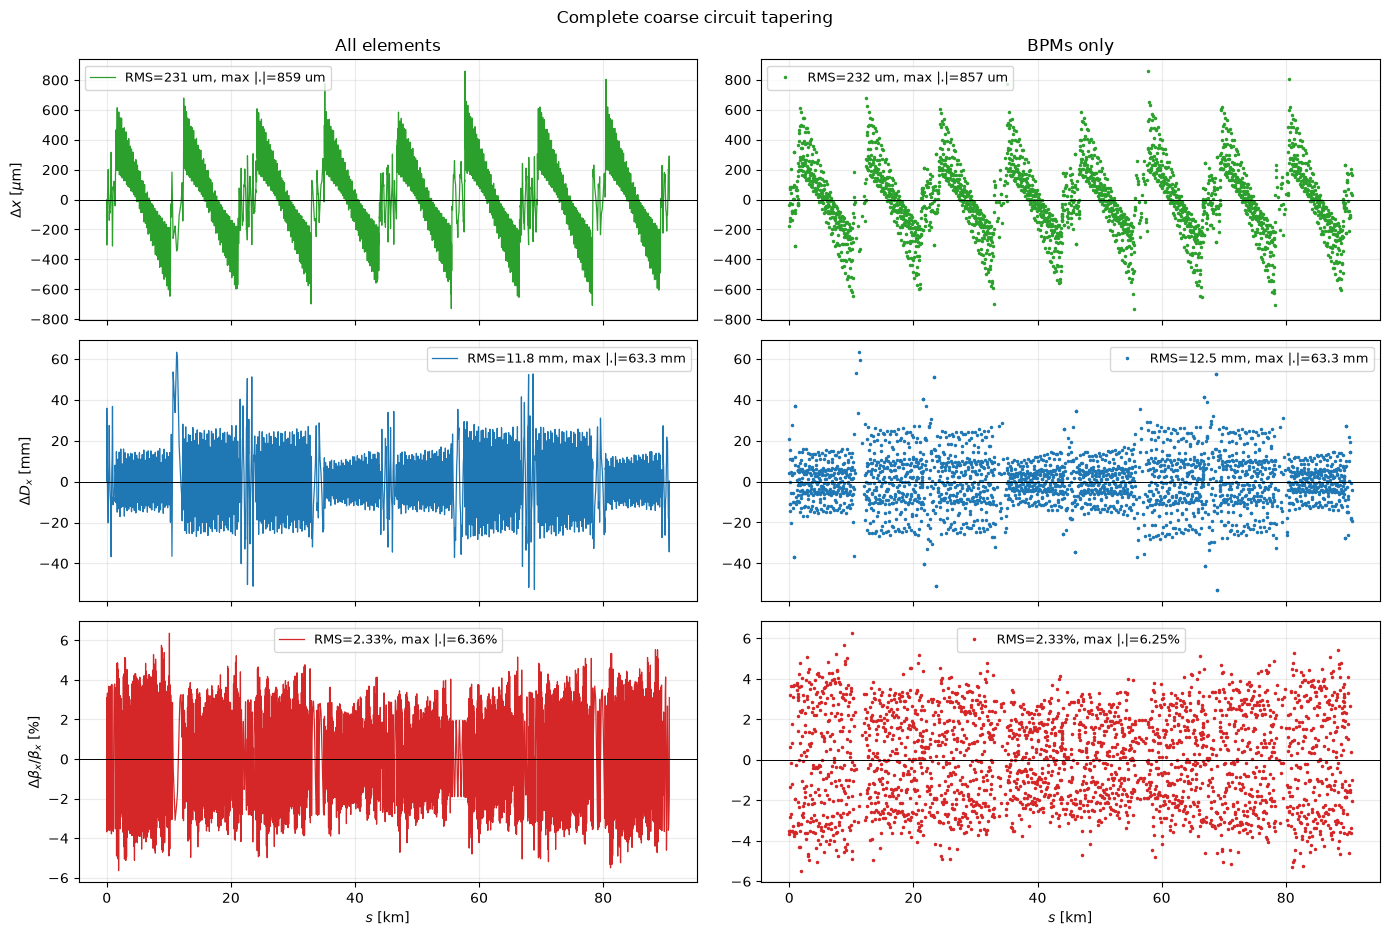

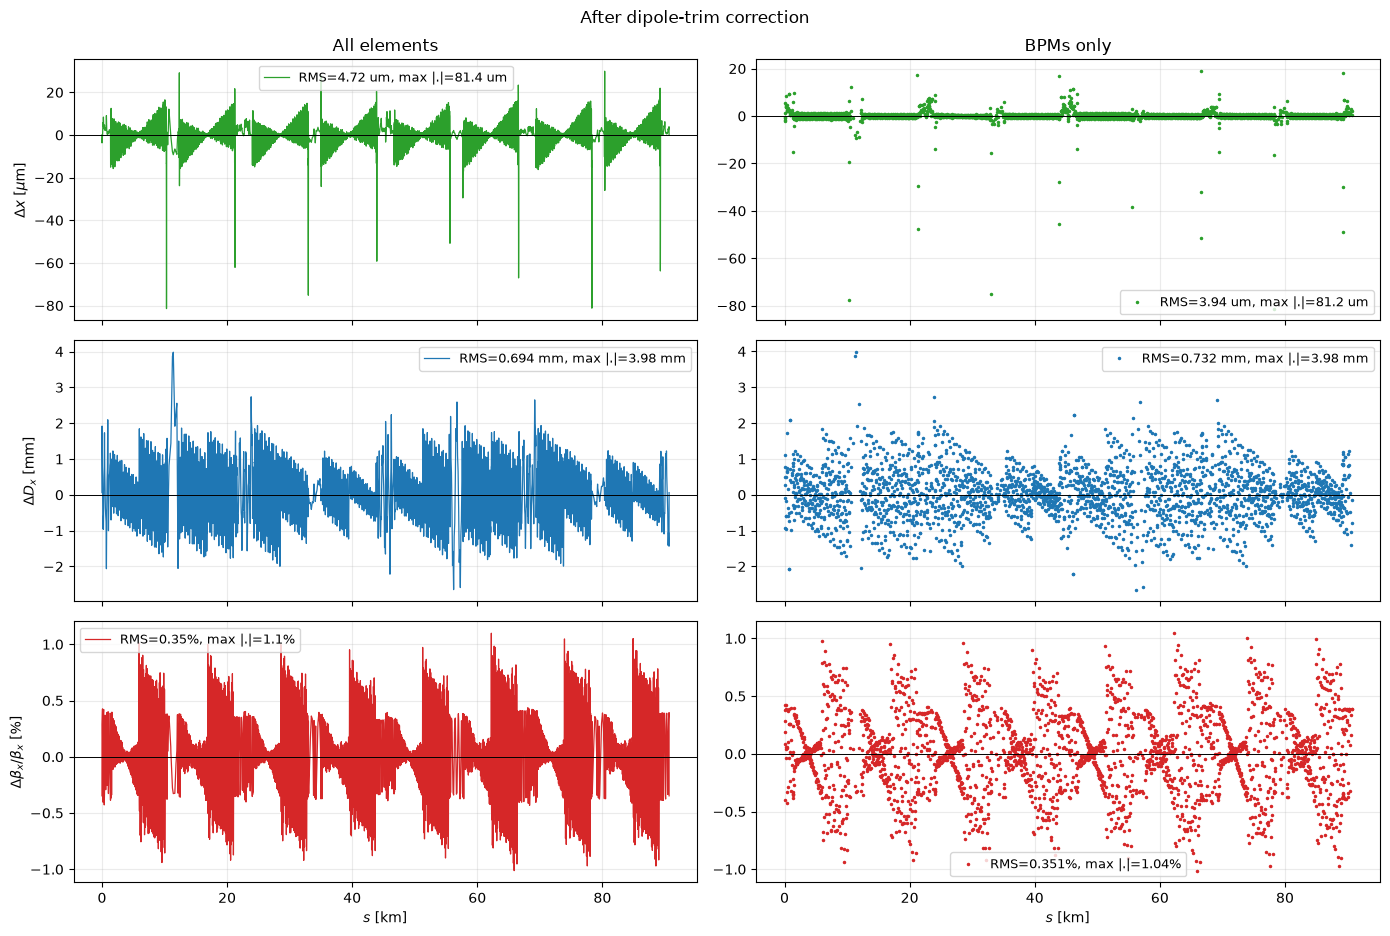

In [46]:
def plot_horizontal_optics_case(twiss_case, reference, label, bpm_names):
    bpm_names = list(np.asarray(bpm_names, dtype=str))

    # All Twiss locations
    s_all_km = np.asarray(reference.s, dtype=float) / 1e3
    delta_orbit_x_all_um = 1e6 * (
        np.asarray(twiss_case.x, dtype=float)
        - np.asarray(reference.x, dtype=float)
    )
    delta_dispersion_all_mm = 1e3 * (
        np.asarray(twiss_case.dx, dtype=float)
        - np.asarray(reference.dx, dtype=float)
    )
    beta_beating_all_percent = 100.0 * (
        np.asarray(twiss_case.betx, dtype=float)
        / np.asarray(reference.betx, dtype=float) - 1.0
    )

    # BPM locations only. Obtain the indices independently from each table.
    reference_bpm_indices = reference.rows.indices[bpm_names]
    case_bpm_indices = twiss_case.rows.indices[bpm_names]
    s_bpm_km = np.asarray(reference.s[reference_bpm_indices], dtype=float) / 1e3
    delta_orbit_x_bpm_um = 1e6 * (
        np.asarray(twiss_case.x[case_bpm_indices], dtype=float)
        - np.asarray(reference.x[reference_bpm_indices], dtype=float)
    )
    delta_dispersion_bpm_mm = 1e3 * (
        np.asarray(twiss_case.dx[case_bpm_indices], dtype=float)
        - np.asarray(reference.dx[reference_bpm_indices], dtype=float)
    )
    beta_beating_bpm_percent = 100.0 * (
        np.asarray(twiss_case.betx[case_bpm_indices], dtype=float)
        / np.asarray(reference.betx[reference_bpm_indices], dtype=float) - 1.0
    )

    def statistics(values):
        values = np.asarray(values, dtype=float)
        return np.sqrt(np.nanmean(values**2)), np.nanmax(np.abs(values))

    orbit_all_rms, orbit_all_max = statistics(delta_orbit_x_all_um)
    orbit_bpm_rms, orbit_bpm_max = statistics(delta_orbit_x_bpm_um)
    dx_all_rms, dx_all_max = statistics(delta_dispersion_all_mm)
    dx_bpm_rms, dx_bpm_max = statistics(delta_dispersion_bpm_mm)
    betx_all_rms, betx_all_max = statistics(beta_beating_all_percent)
    betx_bpm_rms, betx_bpm_max = statistics(beta_beating_bpm_percent)

    fig, axes = plt.subplots(3, 2, figsize=(14, 9.5), sharex='col')
    axes[0, 0].plot(s_all_km, delta_orbit_x_all_um, color='tab:green', lw=0.9,
                    label=f'RMS={orbit_all_rms:.3g} um, max |.|={orbit_all_max:.3g} um')
    axes[0, 1].plot(s_bpm_km, delta_orbit_x_bpm_um, '.', color='tab:green', ms=3,
                    label=f'RMS={orbit_bpm_rms:.3g} um, max |.|={orbit_bpm_max:.3g} um')
    axes[1, 0].plot(s_all_km, delta_dispersion_all_mm, color='tab:blue', lw=0.9,
                    label=f'RMS={dx_all_rms:.3g} mm, max |.|={dx_all_max:.3g} mm')
    axes[1, 1].plot(s_bpm_km, delta_dispersion_bpm_mm, '.', color='tab:blue', ms=3,
                    label=f'RMS={dx_bpm_rms:.3g} mm, max |.|={dx_bpm_max:.3g} mm')
    axes[2, 0].plot(s_all_km, beta_beating_all_percent, color='tab:red', lw=0.9,
                    label=f'RMS={betx_all_rms:.3g}%, max |.|={betx_all_max:.3g}%')
    axes[2, 1].plot(s_bpm_km, beta_beating_bpm_percent, '.', color='tab:red', ms=3,
                    label=f'RMS={betx_bpm_rms:.3g}%, max |.|={betx_bpm_max:.3g}%')

    axes[0, 0].set_title('All elements')
    axes[0, 1].set_title('BPMs only')
    axes[0, 0].set_ylabel(r'$\Delta x$ [$\mu$m]')
    axes[1, 0].set_ylabel(r'$\Delta D_x$ [mm]')
    axes[2, 0].set_ylabel(r'$\Delta\beta_x/\beta_x$ [%]')
    axes[2, 0].set_xlabel(r'$s$ [km]')
    axes[2, 1].set_xlabel(r'$s$ [km]')

    for ax in axes.flat:
        ax.axhline(0.0, color='black', lw=0.7)
        ax.grid(alpha=0.25)
        ax.legend(fontsize=9)

    fig.suptitle(label)
    fig.tight_layout()
    plt.show()

case_twiss_tables = {
    'No magnet tapering': tw_no_taper,
    'Ideal tapering in insertions': twiss_insertion_taper,
    'Insertions plus dipole circuits': twiss_dipole,
    'Complete coarse circuit tapering': twiss_quad_sext,
    'After dipole-trim correction': twiss_after_dipole_trims,
}

for case_label, case_twiss in case_twiss_tables.items():
    plot_horizontal_optics_case(case_twiss, twiss_ideal, case_label, monitor_names)

# Dipole-trim distribution

In [48]:
# The trim integrated-field distribution was calculated above.
trim_strength_summary = pd.DataFrame({
    'dipole': trim_dipole_names,
    's_km': trim_s_km,
    'kick_urad': 1e6 * trim_kicks_rad,
    'length_m': trim_layout['length_m'].to_numpy(float),
    'integrated_field_mTm': trim_integrated_field_mTm,
})
trim_strength_summary["field mT"] = trim_strength_summary["integrated_field_mTm"] / trim_strength_summary["length_m"]
display(trim_strength_summary.head(12))

,dipole,s_km,kick_urad,length_m,integrated_field_mTm,field mT
0,mbd.0,1.363667,-4.343038,9.613334,-2.643844,-0.275018
1,mbd.3,1.394737,-7.761316,9.613334,-4.724736,-0.491477
2,mbd.6,1.428962,-7.216732,9.613334,-4.393218,-0.456992
3,mbd.9,1.461062,-8.649801,9.613334,-5.265605,-0.547740
4,mbd.12,1.495687,-6.881599,9.613334,-4.189204,-0.435770
5,mbd.15,1.526757,-7.710520,9.613334,-4.693814,-0.488261
6,mbd.18,1.559257,-6.932046,9.613334,-4.219914,-0.438965
7,mbd.21,1.590947,-7.271322,9.613334,-4.426450,-0.460449
8,mbd.24,1.623447,-6.892925,9.613334,-4.196099,-0.436487
9,mbd.27,1.655137,-7.126071,9.613334,-4.338028,-0.451251
